In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kasapogusumithra/loan-approval-decision-tree-in-kaggle/loan.csv")

df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [4]:
df

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved
...,...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770,Approved
57,25,Female,Receptionist,High School,Single,32000,570,Denied
58,43,Male,Banker,Bachelor's,Married,95000,760,Approved
59,30,Female,Writer,Master's,Single,55000,650,Approved


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [8]:
df.isnull().sum()

age                0
gender             0
occupation         0
education_level    0
marital_status     0
income             0
credit_score       0
loan_status        0
dtype: int64

In [24]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/kasapogusumithra/loan-approval-decision-tree-in-kaggle/loan.csv")

print(df.columns)

Index(['age', 'gender', 'occupation', 'education_level', 'marital_status',
       'income', 'credit_score', 'loan_status'],
      dtype='object')


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['occupation'] = le.fit_transform(df['occupation'])
df['education_level'] = le.fit_transform(df['education_level'])
df['marital_status'] = le.fit_transform(df['marital_status'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [27]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print(X.head())
print(y.head())

   age  gender  occupation  education_level  marital_status  income  \
0   32       1          12                1               0   85000   
1   45       0          35                4               1   62000   
2   28       1          33                3               1   25000   
3   51       0          16                1               0  105000   
4   36       1           0                1               0   75000   

   credit_score  
0           720  
1           680  
2           590  
3           780  
4           710  
0    0
1    0
2    1
3    0
4    0
Name: loan_status, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (48, 7)
Testing data: (13, 7)


In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [30]:
y_pred = dt_model.predict(X_test)

print(y_pred[:10])

[0 1 0 0 0 0 1 1 1 0]


In [31]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9 0]
 [0 4]]


In [33]:
import pandas as pd

importance = dt_model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

print(feature_importance.sort_values(ascending=False))

income             1.0
gender             0.0
age                0.0
occupation         0.0
education_level    0.0
marital_status     0.0
credit_score       0.0
dtype: float64


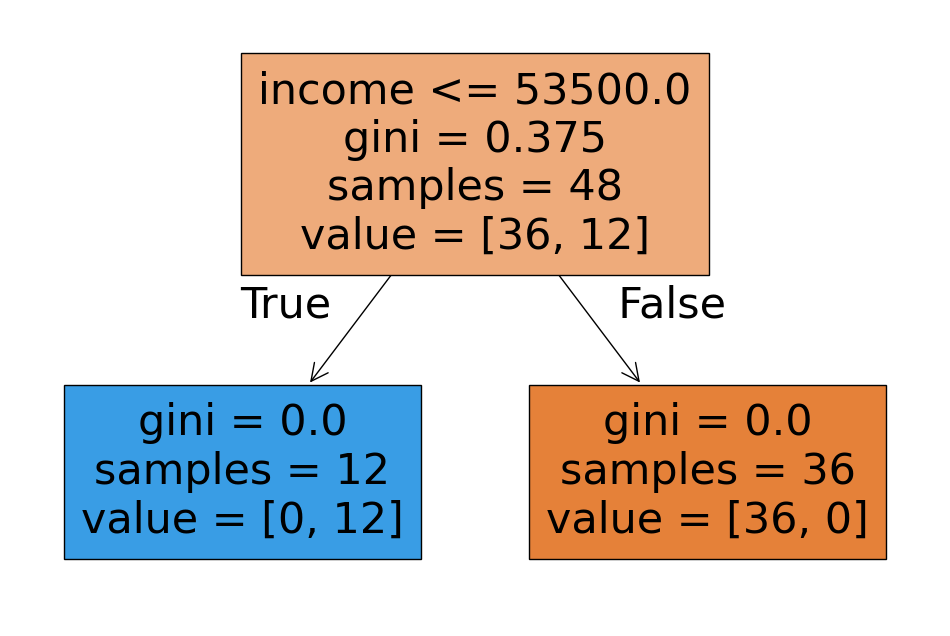

In [34]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=X.columns, filled=True)
plt.show()

In [35]:
df = df[['gender', 'education_level', 'age', 'loan_status']]
df

,gender,education_level,age,loan_status
0,1,1,32,0
1,0,4,45,0
2,1,3,28,1
3,0,1,51,0
4,1,1,36,0
...,...,...,...,...
56,1,4,39,0
57,0,3,25,1
58,1,1,43,0
59,0,4,30,0


In [36]:
from sklearn.preprocessing import StandardScaler

# one hot encoding
df_encoded = pd.get_dummies(df, columns=['gender', 'education_level'])

# scaling - note this is optional for trees algo
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded[['age']])
df_scaled = pd.DataFrame(scaled_features, columns=['scaled_age'])
df_final = pd.concat([df_encoded, df_scaled], axis=1).drop(columns=['age'])

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# split data into features and labels
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1, random_state=42)

# create a Decision Tree Classifier model
clf = DecisionTreeClassifier(criterion='gini')

# train the model
clf = clf.fit(X_train, y_train)

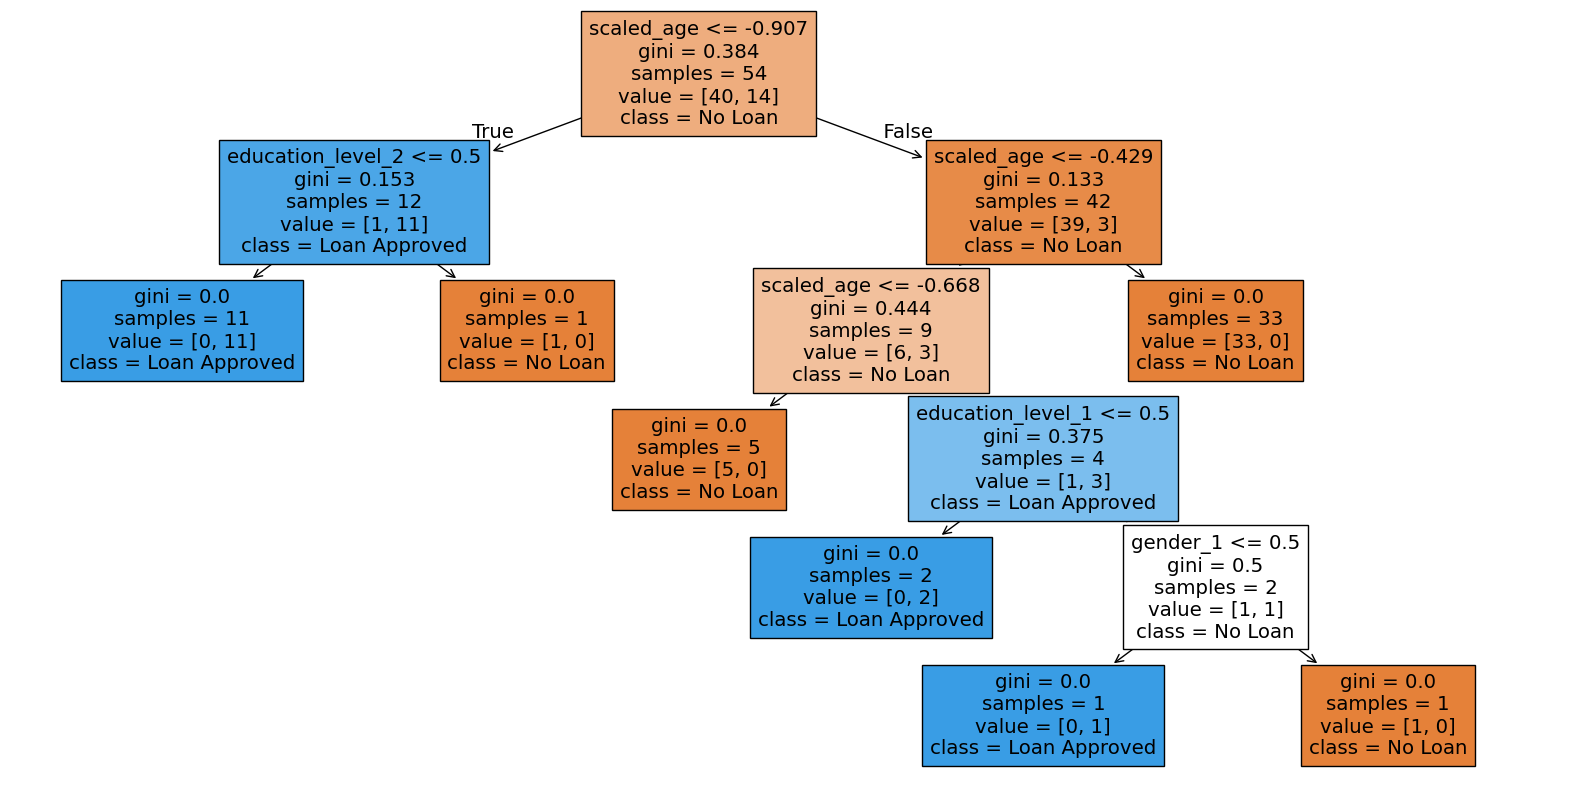

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No Loan', 'Loan Approved'],  # important change
    filled=True
)

plt.show()

In [49]:
print(X.columns)
print(len(X.columns))

print(len(dt_model.feature_importances_))

Index(['gender', 'education_level', 'age'], dtype='object')
3
7


In [50]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [51]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X, y)

DecisionTreeClassifier()

In [53]:
importance = dt_model.feature_importances_

for i,v in enumerate(importance):
    print(X.columns[i], ":", v)

gender : 0.04236111111111113
education_level : 0.08472222222222225
age : 0.8729166666666667


In [54]:
importance = dt_model.feature_importances_

for i,v in enumerate(importance):
    print(X.columns[i], ":", v)

gender : 0.04236111111111113
education_level : 0.08472222222222225
age : 0.8729166666666667


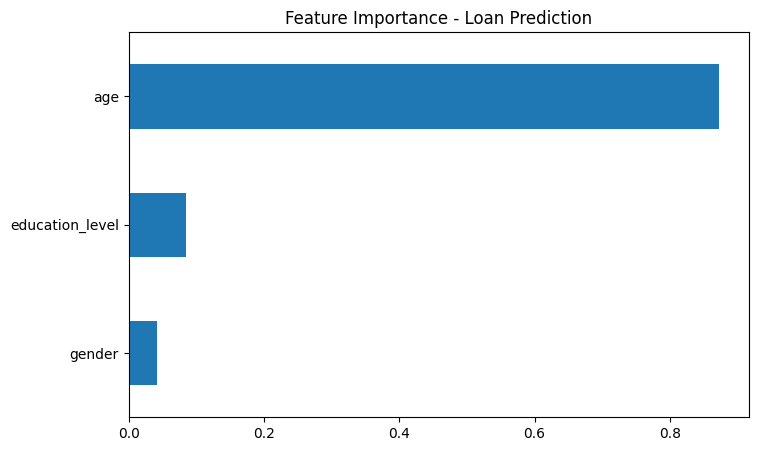

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(importance, index=X.columns)

plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance - Loan Prediction")
plt.show()

In [57]:
import pickle

# Save trained model
with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(dt_model, f)

print("Model saved successfully")

Model saved successfully
